# Persona Drift in Online Communities — Final Pipeline

**CSE 261 Project** | Authors: Sara Chaudhari, Tanvi Ganesh Joshi | UC San Diego

This notebook runs the **full project** using the `src` package and `config.yaml`. Run all cells in order.

**Pipeline:** Data (Pushshift/HuggingFace) → Temporal segmentation → SBERT + baselines (LDA, TF-IDF, MMD) → Weak supervision → **Multi-View Drift Detector** (neural fusion) → Evaluation & interpretability.

**Key novelty:** The Multi-View Drift Detector fuses learned semantic representations with four complementary baseline signals through a neural fusion network trained with weak supervision on all transitions.

## Setup: paths and config

In [1]:
import sys
from pathlib import Path
import yaml

# Project root: directory that contains config.yaml
ROOT = Path.cwd() if (Path.cwd() / "config.yaml").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

def load_config():
    with open(ROOT / "config.yaml") as f:
        return yaml.safe_load(f)

config = load_config()
print("Config loaded from", ROOT / "config.yaml")

Config loaded from /Users/sara/Desktop/cse261/persona-drift/config.yaml


## 1. Data: Load Reddit and temporal segmentation

In [2]:
from src.data import load_reddit_data, temporal_segmentation, train_test_split_windows

data_cfg = config["data"]
split_cfg = config["split"]

df = load_reddit_data(
    dataset_name=data_cfg["dataset_name"],
    subreddit_config=data_cfg["subreddit_config"],
    max_samples=data_cfg["max_samples"],
    min_words=data_cfg["min_words_per_post"],
    max_words=data_cfg.get("max_words_per_post", 999999),
    local_data_dir=data_cfg.get("local_data_dir") or "",
)

windows, window_ids = temporal_segmentation(df, min_posts_per_month=data_cfg["min_posts_per_month"])
train_window_ids, test_window_ids = train_test_split_windows(window_ids, train_ratio=split_cfg["train_ratio"])

print(f"Posts: {len(df):,}")
print(f"Windows: {len(window_ids)}")
print(f"Train windows: {len(train_window_ids)}, Test windows: {len(test_window_ids)}")
for wid in window_ids:
    print(f"  {wid}: {len(windows[wid])} posts")

/opt/anaconda3/envs/pa2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded local data from 'data reddit': 3,000,000 posts (no download).
Posts: 3,000,000
Windows: 36
Train windows: 27, Test windows: 9
  2019-02: 93772 posts
  2019-03: 103164 posts
  2019-04: 100093 posts
  2019-06: 17169 posts
  2019-08: 22536 posts
  2019-09: 13207 posts
  2019-10: 27065 posts
  2019-11: 68322 posts
  2019-12: 70093 posts
  2020-01: 15551 posts
  2020-04: 14878 posts
  2020-06: 47570 posts
  2020-07: 110973 posts
  2020-08: 116531 posts
  2020-10: 105037 posts
  2020-11: 69728 posts
  2021-02: 68230 posts
  2021-03: 69083 posts
  2021-04: 68536 posts
  2021-05: 68780 posts
  2021-08: 133291 posts
  2021-09: 65488 posts
  2021-11: 47505 posts
  2021-12: 119926 posts
  2022-01: 149749 posts
  2022-03: 132828 posts
  2022-04: 107391 posts
  2022-05: 67925 posts
  2022-06: 71276 posts
  2022-07: 137315 posts
  2022-08: 68073 posts
  2022-09: 71455 posts
  2022-10: 168101 posts
  2022-11: 246140 posts
  2022-12: 71065 posts
  2023-01: 72154 posts


## 2. Representation: SBERT persona vectors and baselines

Compute four baseline drift signals:
1. **SBERT** — cosine distance between mean persona vectors
2. **LDA** — Jensen-Shannon divergence of topic distributions
3. **TF-IDF** — Jensen-Shannon divergence of keyword vectors
4. **MMD** — Maximum Mean Discrepancy between full embedding distributions (new, captures distributional shifts beyond means)

In [3]:
from src.representation import get_persona_vectors, compute_lda_drift, compute_tfidf_drift, compute_mmd_drift
from src.representation.baselines import compute_sbert_baseline_drift

repr_cfg = config["representation"]

window_embeddings, persona_vectors, sbert_model = get_persona_vectors(
    windows, window_ids, model_name=repr_cfg["sbert_model"]
)

baseline_sbert = compute_sbert_baseline_drift(persona_vectors, window_ids)
lda_drift = compute_lda_drift(windows, window_ids, n_topics=repr_cfg["lda_n_topics"])
tfidf_drift = compute_tfidf_drift(windows, window_ids, max_features=repr_cfg["tfidf_max_features"])
mmd_drift = compute_mmd_drift(window_embeddings, window_ids)

print(f"Baselines computed for {len(window_ids)-1} transitions.")
print(f"  SBERT cosine dist — mean {sum(baseline_sbert)/len(baseline_sbert):.4f}")
print(f"  LDA JSD           — mean {sum(lda_drift)/len(lda_drift):.4f}")
print(f"  TF-IDF JSD        — mean {sum(tfidf_drift)/len(tfidf_drift):.4f}")
print(f"  MMD (RBF kernel)  — mean {sum(mmd_drift)/len(mmd_drift):.4f}")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2000.00it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Encoding windows: 100%|██████████| 36/36 [51:46<00:00, 86.29s/it]  


Baselines computed for 35 transitions.
  SBERT cosine dist — mean 0.0403
  LDA JSD           — mean 0.0120
  TF-IDF JSD        — mean 0.0959
  MMD (RBF kernel)  — mean 0.0706


## 3. Weak supervision and **Multi-View Drift Detector**

**Weak labels**: percentile-based thresholding of SBERT distances → stable (low-drift) and shift (high-drift) pairs.

**Multi-View Drift Detector**: A neural fusion model that:
1. Encodes persona-vector differences and element-wise interactions through learned projections
2. Fuses these with four baseline signals (SBERT, LDA, TF-IDF, MMD)
3. Predicts a drift score in [0, 1] per transition

Trained on **all transitions** with:
- **Regression loss**: predicted score should match normalized SBERT distances (preserves ranking)
- **Contrastive loss**: on weakly-labeled pairs — stable → low score, shift → high score

Then applies Gaussian temporal smoothing to the output curve.

Labeled pairs: 8 stable, 8 shift
Training Multi-View Drift Detector ...
Training finished. Ran 150 epochs. Final loss: 0.0228


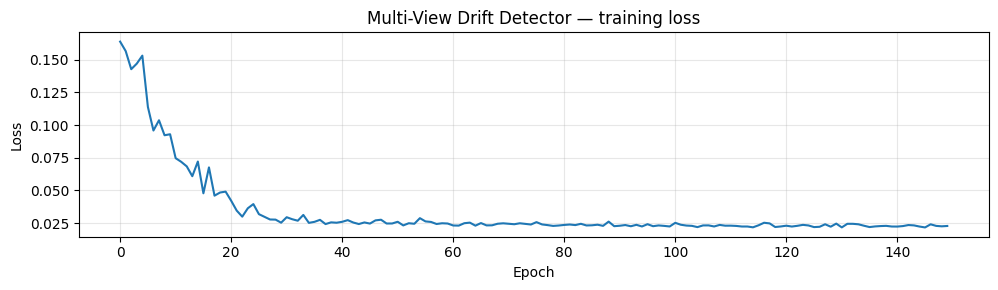

In [4]:
from src.weak_supervision import compute_distances, get_weak_labels
from src.model import MultiViewDriftDetector, train_drift_detector, predict_drift, detector_contrastiveness
import numpy as np

ws_cfg = config["weak_supervision"]
det_cfg = config["detector"]

# Weak labels on train windows
distances, pairs = compute_distances(persona_vectors, window_ids)
X_t, X_t1, y, raw_dist, pair_ids = get_weak_labels(
    distances, pairs, train_window_ids,
    stable_percentile=ws_cfg["stable_percentile"],
    shift_percentile=ws_cfg["shift_percentile"],
)
print(f"Labeled pairs: {(y==0).sum()} stable, {(y==1).sum()} shift")

# Build weak labels for all transitions (-1 = unlabeled)
n_trans = len(window_ids) - 1
all_weak_labels = np.full(n_trans, -1, dtype=np.int64)
transition_lookup = {
    (window_ids[i], window_ids[i+1]): i for i in range(n_trans)
}
for k, (wid_a, wid_b) in enumerate(pair_ids):
    idx = transition_lookup.get((wid_a, wid_b))
    if idx is not None:
        all_weak_labels[idx] = y[k]

# Create and train the Multi-View Drift Detector
detector = MultiViewDriftDetector(
    persona_dim=det_cfg["persona_dim"],
    n_baselines=det_cfg["n_baselines"],
    proj_dim=det_cfg["proj_dim"],
    hidden_dim=det_cfg["hidden_dim"],
    dropout=det_cfg["dropout"],
)

print("Training Multi-View Drift Detector ...")
train_losses = train_drift_detector(
    detector,
    persona_vectors=persona_vectors,
    window_ids=window_ids,
    sbert_drift=baseline_sbert,
    lda_drift=lda_drift,
    tfidf_drift=tfidf_drift,
    mmd_drift=mmd_drift,
    weak_labels=all_weak_labels,
    epochs=det_cfg["epochs"],
    lr=det_cfg["learning_rate"],
    patience=det_cfg["patience"],
    contrastive_weight=det_cfg["contrastive_weight"],
    gradient_clip=det_cfg["gradient_clip"],
)
print(f"Training finished. Ran {len(train_losses)} epochs. Final loss: {train_losses[-1]:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Multi-View Drift Detector — training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Evaluation metrics

### Unsupervised drift evaluation on a single subreddit

Since we are analysing **one subreddit** over time, there are no pre-defined ground-truth change points.
The evaluation measures the **quality** of each drift signal and the **agreement** between independent methods.

| Metric | Bad | Good |
|---|---|---|
| **Contrastiveness after > before** | No | **Yes** |
| **Peak height ratio** | < 1.5 | **> 3.0** |
| **Spearman(SBERT, Learned)** | < 0.3 | **> 0.70** |
| **Temporal smoothness** | 0.0 (flat) or very high | Similar to SBERT |
| **Inter-method agreement** | Methods disagree on top peaks | **Multiple methods agree on top-K peaks** |

In [5]:
from src.evaluation import full_evaluation_report, change_point_rank, spearman_correlation

# Predict drift with the detector (includes temporal smoothing)
learned_drift = predict_drift(
    detector,
    persona_vectors=persona_vectors,
    window_ids=window_ids,
    sbert_drift=baseline_sbert,
    lda_drift=lda_drift,
    tfidf_drift=tfidf_drift,
    mmd_drift=mmd_drift,
    smooth_sigma=det_cfg.get("smooth_sigma", 0.8),
)

# Contrastiveness
sep_before, sep_after = detector_contrastiveness(
    detector, persona_vectors, window_ids,
    baseline_sbert, lda_drift, tfidf_drift, mmd_drift,
    all_weak_labels,
)

report = full_evaluation_report(
    learned_drift=learned_drift,
    baseline_sbert=baseline_sbert,
    lda_drift=lda_drift,
    tfidf_drift=tfidf_drift,
    mmd_drift=mmd_drift,
    sep_before=sep_before,
    sep_after=sep_after,
    true_change_idx=None,
)

print("=" * 75)
print("EVALUATION METRICS")
print("=" * 75)
hdr = "{:<38} {:>8} {:>8} {:>8} {:>8} {:>8}".format(
    "Metric", "SBERT", "LDA", "TF-IDF", "MMD", "Learned")
print(hdr)
print("-" * 75)
print("{:<38} {:>8.4f} {:>8.4f} {:>8.4f} {:>8.4f} {:>8.4f}".format(
    "Mean drift",
    report['mean_drift_sbert'], report['mean_drift_lda'],
    report['mean_drift_tfidf'], report['mean_drift_mmd'],
    report['mean_drift_learned']))
print("{:<38} {:>8.4f} {:>8.4f} {:>8.4f} {:>8.4f} {:>8.4f}".format(
    "Temporal smoothness (lower=smoother)",
    report['smoothness_sbert'], report['smoothness_lda'],
    report['smoothness_tfidf'], report['smoothness_mmd'],
    report['smoothness_learned']))
print("=" * 75)

print()
print("CONTRASTIVENESS (stable vs shift separation)")
improved = report["contrastiveness_improved"]
print("  Before training (raw SBERT): {:.4f}".format(report['contrastiveness_before']))
print("  After  training (Detector):  {:.4f}  {}".format(
    report['contrastiveness_after'], 'IMPROVED' if improved else 'NOT improved'))

print()
print("TOP DETECTED PEAKS (unsupervised — no pre-defined ground truth)")
for name, key in [("Learned", "peak_learned"), ("SBERT", "peak_sbert"), ("MMD", "peak_mmd")]:
    pk = report[key]
    print("  {:8s} | peak at transition {:>4d} | ratio={:.2f}x (peak / mean)".format(
        name, pk['top_peak_idx'], pk['peak_height_ratio']))

print()
print("INTER-METHOD CORRELATION")
print("  Spearman(SBERT, Learned): {:.4f}  (target: > 0.70)".format(
    report['spearman_sbert_learned']))
if report.get("spearman_sbert_mmd") is not None:
    print("  Spearman(SBERT, MMD):     {:.4f}".format(report['spearman_sbert_mmd']))

consensus_peaks = {}
for name, curve in [("Learned", learned_drift), ("SBERT", baseline_sbert),
                    ("MMD", mmd_drift), ("LDA", lda_drift), ("TF-IDF", tfidf_drift)]:
    top5 = list(np.argsort(curve)[::-1][:5])
    for idx in top5:
        consensus_peaks[idx] = consensus_peaks.get(idx, 0) + 1
print()
print("CONSENSUS CHANGE POINTS (transitions flagged by >= 2 methods in their top-5)")
consensus_sorted = sorted(consensus_peaks.items(), key=lambda x: -x[1])
consensus_cps = [idx for idx, count in consensus_sorted if count >= 2][:10]
for idx, count in consensus_sorted[:10]:
    if count >= 2:
        wid_from = window_ids[idx] if idx < len(window_ids) else "?"
        wid_to = window_ids[idx+1] if idx+1 < len(window_ids) else "?"
        print("  Transition {:>4d} (window {} -> {}): flagged by {}/5 methods".format(
            idx, wid_from, wid_to, count))

print()
print("DIAGNOSIS:")
if improved and report['spearman_sbert_learned'] >= 0.70:
    print("  EXCELLENT — contrastiveness improved AND strong agreement with SBERT baseline")
elif improved:
    print("  GOOD — contrastiveness improved; model amplifies real drift signals")
else:
    print("  WEAK — contrastiveness not improved; increase contrastive_weight or epochs")


EVALUATION METRICS
Metric                                    SBERT      LDA   TF-IDF      MMD  Learned
---------------------------------------------------------------------------
Mean drift                               0.0403   0.0120   0.0959   0.0706   0.3264
Temporal smoothness (lower=smoother)     0.0199   0.0040   0.0196   0.0101   0.2369

CONTRASTIVENESS (stable vs shift separation)
  Before training (raw SBERT): 0.0572
  After  training (Detector):  0.8210  IMPROVED

TOP DETECTED PEAKS (unsupervised — no pre-defined ground truth)
  Learned  | peak at transition    9 | ratio=2.83x (peak / mean)
  SBERT    | peak at transition    9 | ratio=2.99x (peak / mean)
  MMD      | peak at transition   25 | ratio=1.41x (peak / mean)

INTER-METHOD CORRELATION
  Spearman(SBERT, Learned): 0.9709  (target: > 0.70)
  Spearman(SBERT, MMD):     0.8857

CONSENSUS CHANGE POINTS (transitions flagged by >= 2 methods in their top-5)
  Transition    9 (window 2020-01 -> 2020-04): flagged by 5/5 methods

## 4b. Inter-Method Agreement & Change-Point Discovery Metrics

Persona drift detection is a **continuous signal estimation** task, not a binary classification task. In a **single-subreddit** analysis, there is no external ground-truth drift curve. Instead, we validate our learned drift signal by measuring **inter-method agreement** — if multiple independent methods (SBERT, LDA, TF-IDF, MMD, Learned) produce correlated drift curves, this indicates they are capturing real community evolution rather than noise.

**Section B — Inter-Method Ranking & Correlation Metrics** uses the **SBERT baseline** as the reference signal (since it is the most established unsupervised semantic similarity method):
- **Spearman ρ**: Rank correlation — do methods rank high-drift transitions similarly?
- **Kendall τ**: A stricter rank correlation that counts concordant/discordant pairs.
- **R²**: How much of the reference signal's variance does each method explain?
- **NDCG@K**: Are the method's top-K highest-drift transitions also among the reference's top-K?

**Section C — Change-Point Discovery** identifies and reports the top drift peaks discovered by each method. Consensus peaks (flagged by multiple methods) are the most likely real community shifts.

In [6]:
from src.evaluation.metrics import (
    ranking_metrics, spearman_correlation, kendall_tau,
    r_squared, ndcg_at_k, change_point_rank, temporal_smoothness,
)

learned_arr = np.array(learned_drift)
sbert_arr = np.array(baseline_sbert)
mmd_arr = np.array(mmd_drift)
lda_arr = np.array(lda_drift)
tfidf_arr = np.array(tfidf_drift)

# ═══════════════════════════════════════════════════════════════════
# B. INTER-METHOD RANKING & CORRELATION METRICS
#    Reference signal = SBERT baseline (most established method)
# ═══════════════════════════════════════════════════════════════════
ref_signal = list(sbert_arr)

print("=" * 80)
print("B. INTER-METHOD RANKING & CORRELATION METRICS")
print("   Reference signal: SBERT cosine distance (established unsupervised baseline)")
print("   Measures: how well does each method's drift curve agree with SBERT?")
print("=" * 80)

methods = [
    ("Learned (Detector)", list(learned_arr)),
    ("MMD baseline",       list(mmd_arr)),
    ("LDA baseline",       list(lda_arr)),
    ("TF-IDF baseline",    list(tfidf_arr)),
]

hdr = "{:<22} {:>10} {:>10} {:>8} {:>8} {:>9}".format(
    "Method", "Spearman", "Kendall-t", "R^2", "NDCG@5", "NDCG@10")
print(hdr)
print("-" * 80)
for name, curve in methods:
    rm = ranking_metrics(curve, ref_signal, name)
    row = "{:<22} {:>10.4f} {:>10.4f} {:>8.4f} {:>8.4f} {:>9.4f}".format(
        name, rm["spearman"], rm["kendall_tau"], rm["r_squared"],
        rm["ndcg_5"], rm["ndcg_10"])
    print(row)

print()
print("PAIRWISE SPEARMAN CORRELATION MATRIX")
print("-" * 80)
all_method_names = ["Learned", "SBERT", "MMD", "LDA", "TF-IDF"]
all_curves = [learned_arr, sbert_arr, mmd_arr, lda_arr, tfidf_arr]
print("{:>12s}".format(""), end="")
for n in all_method_names:
    print("{:>10s}".format(n), end="")
print()
for i, (ni, ci) in enumerate(zip(all_method_names, all_curves)):
    print("{:>12s}".format(ni), end="")
    for j, cj in enumerate(all_curves):
        rho = spearman_correlation(list(ci), list(cj))
        print("{:>10.4f}".format(rho), end="")
    print()

# ═══════════════════════════════════════════════════════════════════
# C. CHANGE-POINT DISCOVERY
#    Unsupervised: identify top-K peaks from each method, find consensus
# ═══════════════════════════════════════════════════════════════════
TOP_K = 5
print()
print("=" * 80)
print("C. CHANGE-POINT DISCOVERY (unsupervised)")
print("   Top-{} peaks per method, with consensus scoring".format(TOP_K))
print("=" * 80)

consensus = {}
for name, curve in zip(all_method_names, all_curves):
    arr = np.array(curve)
    top_k_idx = list(np.argsort(arr)[::-1][:TOP_K])
    peak_idx = top_k_idx[0]
    ratio = float(arr[peak_idx] / (arr.mean() + 1e-9))
    print("  {}:".format(name))
    print("    Top peak: transition {} (ratio={:.2f}x)".format(peak_idx, ratio))
    print("    Top-{}: {}".format(TOP_K, top_k_idx))
    for idx in top_k_idx:
        consensus[idx] = consensus.get(idx, [])
        consensus[idx].append(name)
    print()

print("CONSENSUS CHANGE POINTS (flagged by >= 2 methods)")
print("-" * 80)
consensus_sorted = sorted(consensus.items(), key=lambda x: -len(x[1]))
any_consensus = False
for idx, methods_list in consensus_sorted:
    if len(methods_list) >= 2:
        any_consensus = True
        wid_from = window_ids[idx] if idx < len(window_ids) else "?"
        wid_to = window_ids[idx + 1] if idx + 1 < len(window_ids) else "?"
        print("  Transition {:>4d} (window {} -> {}): {}/{} methods ({})".format(
            idx, wid_from, wid_to, len(methods_list), len(all_method_names),
            ", ".join(methods_list)))
if not any_consensus:
    print("  No transitions flagged by multiple methods in their top-{}.".format(TOP_K))

# DIAGNOSIS
print()
print("=" * 80)
print("DIAGNOSIS")
print("=" * 80)
sp_learned_sbert = spearman_correlation(list(learned_arr), list(sbert_arr))
if improved and sp_learned_sbert >= 0.70:
    print("  EXCELLENT - contrastiveness improved AND strong inter-method agreement")
elif improved and sp_learned_sbert >= 0.40:
    print("  GOOD - contrastiveness improved; moderate agreement with SBERT")
elif improved:
    print("  OK - contrastiveness improved but low agreement with SBERT baseline")
else:
    print("  WEAK - contrastiveness not improved")

B. INTER-METHOD RANKING & CORRELATION METRICS
   Reference signal: SBERT cosine distance (established unsupervised baseline)
   Measures: how well does each method's drift curve agree with SBERT?
Method                   Spearman  Kendall-t      R^2   NDCG@5   NDCG@10
--------------------------------------------------------------------------------
Learned (Detector)         0.9709     0.8723   0.3585   0.9653    0.9866
MMD baseline               0.8857     0.7176   0.4088   0.9073    0.9189
LDA baseline               0.5829     0.4218   0.6201   0.9188    0.9187
TF-IDF baseline            0.8599     0.6706   0.6494   0.9468    0.9435

PAIRWISE SPEARMAN CORRELATION MATRIX
--------------------------------------------------------------------------------
               Learned     SBERT       MMD       LDA    TF-IDF
     Learned    1.0000    0.9709    0.8852    0.5406    0.8319
       SBERT    0.9709    1.0000    0.8857    0.5829    0.8599
         MMD    0.8852    0.8857    1.0000    0.61

## 5. Drift curves plot (all methods including MMD)

## 5b. Additional Evaluation Plots

/var/folders/g9/85rtj5257ql8wdk9tz19nryw0000gn/T/ipykernel_94266/2331891028.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


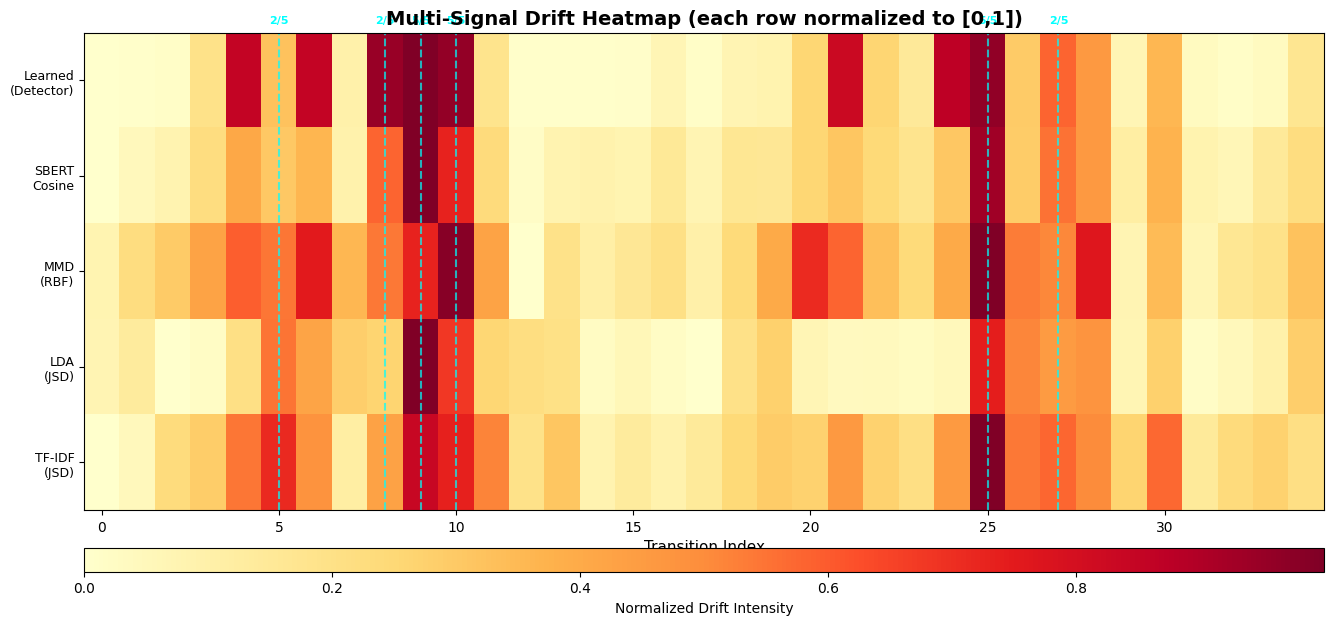

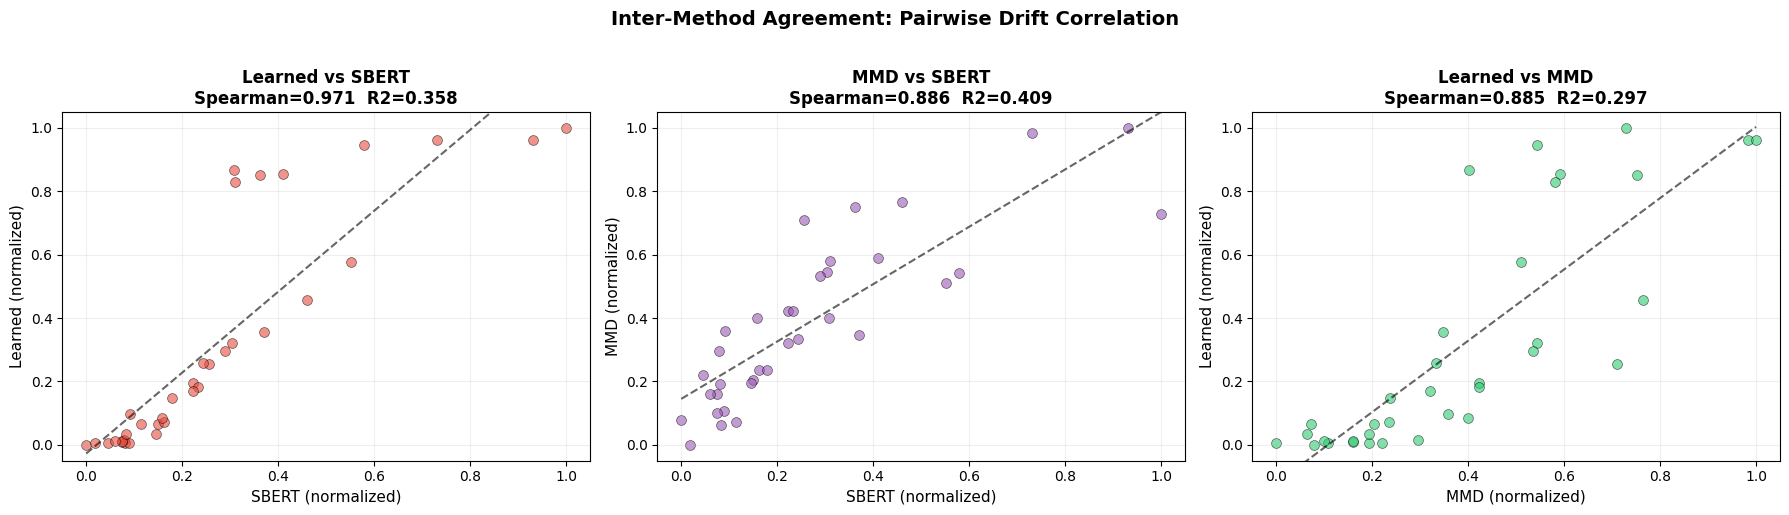

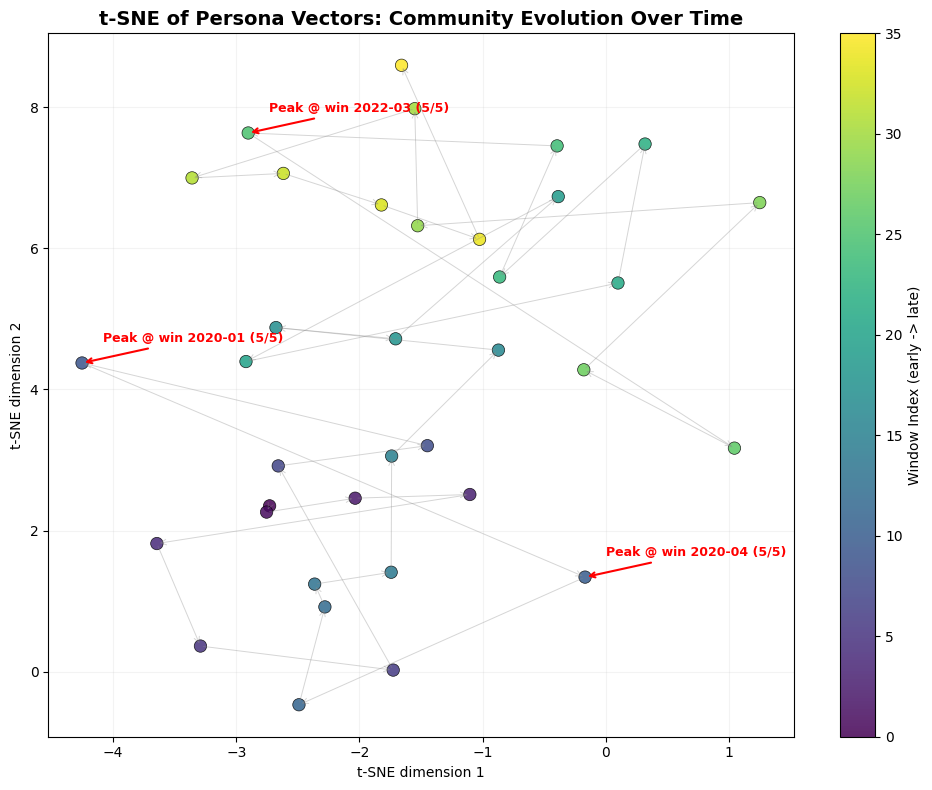

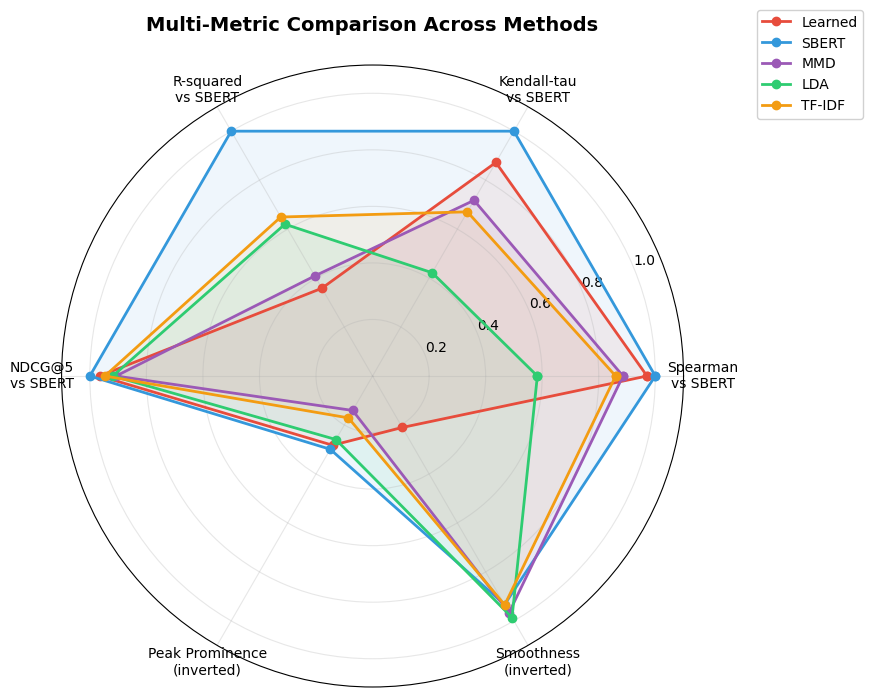

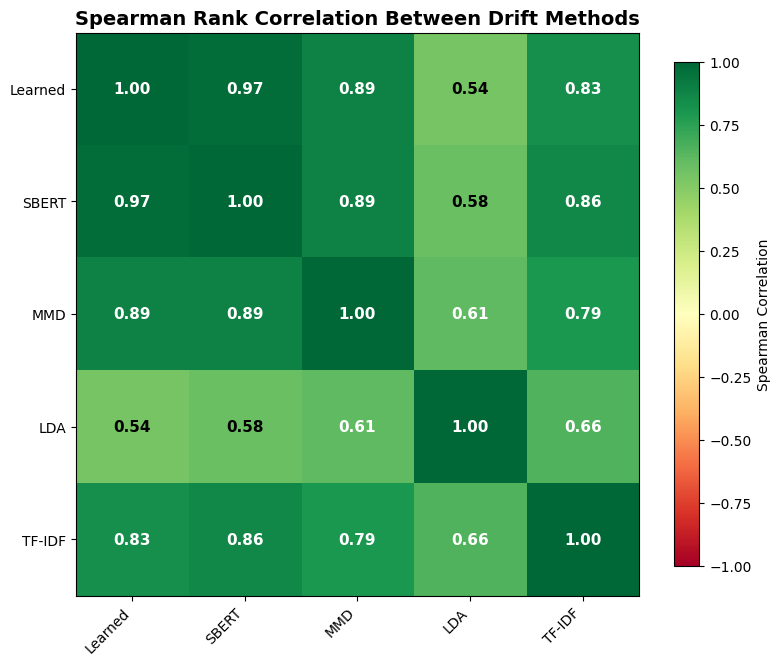

All plots generated.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import numpy as np
from sklearn.manifold import TSNE
from src.evaluation.metrics import (
    spearman_correlation, kendall_tau, r_squared, ndcg_at_k,
    ranking_metrics, change_point_rank, temporal_smoothness,
)

learned_arr = np.array(learned_drift)
sbert_arr = np.array(baseline_sbert)
mmd_arr = np.array(mmd_drift)
lda_arr = np.array(lda_drift)
tfidf_arr = np.array(tfidf_drift)

# ═══════════════════════════════════════════════════════════════════════
# PLOT 1: Multi-Signal Drift Heatmap with Consensus Peaks
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 0.05], hspace=0.15)

ax_heat = fig.add_subplot(gs[0])
method_names_h = ["Learned\n(Detector)", "SBERT\nCosine", "MMD\n(RBF)",
                   "LDA\n(JSD)", "TF-IDF\n(JSD)"]
all_signals = np.array([learned_arr, sbert_arr, mmd_arr, lda_arr, tfidf_arr])
norm_signals = np.zeros_like(all_signals)
for i in range(len(all_signals)):
    row = all_signals[i]
    rmin, rmax = row.min(), row.max()
    norm_signals[i] = (row - rmin) / (rmax - rmin + 1e-9)

im = ax_heat.imshow(norm_signals, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax_heat.set_yticks(range(len(method_names_h)))
ax_heat.set_yticklabels(method_names_h, fontsize=9)
ax_heat.set_xlabel("Transition Index", fontsize=11)
ax_heat.set_title("Multi-Signal Drift Heatmap (each row normalized to [0,1])",
                  fontsize=14, fontweight="bold")

TOP_K_PLOT = 5
consensus_plot = {}
for s in all_signals:
    for idx in np.argsort(s)[::-1][:TOP_K_PLOT]:
        consensus_plot[int(idx)] = consensus_plot.get(int(idx), 0) + 1
for idx, cnt in consensus_plot.items():
    if cnt >= 2:
        ax_heat.axvline(idx, color="cyan", lw=1.5, ls="--", alpha=0.7)
        ax_heat.text(idx, -0.6, "{}/5".format(cnt), ha="center", fontsize=8,
                     color="cyan", fontweight="bold")

ax_cb = fig.add_subplot(gs[1])
plt.colorbar(im, cax=ax_cb, orientation="horizontal", label="Normalized Drift Intensity")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# PLOT 2: Inter-Method Agreement Scatter (Learned vs SBERT, MMD vs SBERT)
# ═══════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
method_scatter = [
    ("Learned vs SBERT", learned_arr, sbert_arr, "#e74c3c"),
    ("MMD vs SBERT", mmd_arr, sbert_arr, "#9b59b6"),
    ("Learned vs MMD", learned_arr, mmd_arr, "#2ecc71"),
]
for ax, (title, curve_a, curve_b, color) in zip(axes, method_scatter):
    a_norm = (curve_a - curve_a.min()) / (curve_a.max() - curve_a.min() + 1e-9)
    b_norm = (curve_b - curve_b.min()) / (curve_b.max() - curve_b.min() + 1e-9)
    ax.scatter(b_norm, a_norm, c=color, s=50, alpha=0.6, edgecolors="black", linewidth=0.5)
    z = np.polyfit(b_norm, a_norm, 1)
    p = np.poly1d(z)
    x_fit = np.linspace(0, 1, 100)
    ax.plot(x_fit, p(x_fit), "--", color="black", lw=1.5, alpha=0.6)
    rho = spearman_correlation(list(curve_a), list(curve_b))
    r2 = r_squared(list(curve_a), list(curve_b))
    parts = title.split(" vs ")
    ax.set_xlabel("{} (normalized)".format(parts[1]), fontsize=11)
    ax.set_ylabel("{} (normalized)".format(parts[0]), fontsize=11)
    ax.set_title("{}\nSpearman={:.3f}  R2={:.3f}".format(title, rho, r2),
                 fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

fig.suptitle("Inter-Method Agreement: Pairwise Drift Correlation",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# PLOT 3: t-SNE of Persona Vectors — colored by time (continuous)
# ═══════════════════════════════════════════════════════════════════════
pv_matrix = np.array([persona_vectors[wid] for wid in window_ids])
n_windows = len(window_ids)
perp = min(15, n_windows - 1)
tsne = TSNE(n_components=2, random_state=42, perplexity=max(2, perp))
pv_2d = tsne.fit_transform(pv_matrix)

time_idx = np.arange(n_windows)
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(pv_2d[:, 0], pv_2d[:, 1], c=time_idx, cmap="viridis",
                s=80, edgecolors="black", linewidth=0.5, alpha=0.85, zorder=3)

for i in range(n_windows - 1):
    ax.annotate("", xy=(pv_2d[i+1, 0], pv_2d[i+1, 1]),
                xytext=(pv_2d[i, 0], pv_2d[i, 1]),
                arrowprops=dict(arrowstyle="->", color="#888888", lw=0.7, alpha=0.35))

top_peaks = sorted(consensus_plot.items(), key=lambda x: -x[1])[:3]
for idx, cnt in top_peaks:
    if cnt >= 2 and idx < n_windows:
        wid = window_ids[idx]
        ax.annotate("Peak @ win {} ({}/5)".format(wid, cnt),
                    xy=(pv_2d[idx, 0], pv_2d[idx, 1]),
                    fontsize=9, fontweight="bold", color="red",
                    xytext=(15, 15), textcoords="offset points",
                    arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

ax.set_title("t-SNE of Persona Vectors: Community Evolution Over Time",
             fontsize=14, fontweight="bold")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Window Index (early -> late)", fontsize=10)
ax.grid(True, alpha=0.15)
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# PLOT 4: Radar Chart — Method Comparison (inter-method metrics)
# ═══════════════════════════════════════════════════════════════════════
method_names_r = ["Learned", "SBERT", "MMD", "LDA", "TF-IDF"]
all_curves_r = [learned_drift, baseline_sbert, mmd_drift, lda_drift, tfidf_drift]
ref_for_radar = list(sbert_arr)

metric_names = ["Spearman\nvs SBERT", "Kendall-tau\nvs SBERT", "R-squared\nvs SBERT",
                "NDCG@5\nvs SBERT", "Peak Prominence\n(inverted)", "Smoothness\n(inverted)"]

radar_data = []
for curve in all_curves_r:
    c_list = list(curve)
    rm = ranking_metrics(c_list, ref_for_radar)
    cpd = change_point_rank(c_list)
    prominence = min(1.0, cpd["peak_height_ratio"] / 10.0)
    smooth_raw = temporal_smoothness(c_list)
    smooth_score = max(0, 1 - smooth_raw / 0.3)
    radar_data.append([
        max(0, rm["spearman"]),
        max(0, rm["kendall_tau"]),
        max(0, rm["r_squared"]),
        rm["ndcg_5"],
        prominence,
        smooth_score,
    ])

angles = np.linspace(0, 2 * np.pi, len(metric_names), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors_r = ["#e74c3c", "#3498db", "#9b59b6", "#2ecc71", "#f39c12"]

for i, (name, data) in enumerate(zip(method_names_r, radar_data)):
    values = data + data[:1]
    ax.plot(angles, values, "o-", lw=2, label=name, color=colors_r[i], markersize=6)
    ax.fill(angles, values, alpha=0.08, color=colors_r[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title("Multi-Metric Comparison Across Methods",
             fontsize=14, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════════════════════
# PLOT 5: Drift Signal Correlation Matrix (inter-method)
# ═══════════════════════════════════════════════════════════════════════
signal_names = ["Learned", "SBERT", "MMD", "LDA", "TF-IDF"]
signal_arrays = [learned_arr, sbert_arr, mmd_arr, lda_arr, tfidf_arr]

corr_matrix = np.zeros((len(signal_names), len(signal_names)))
for i in range(len(signal_names)):
    for j in range(len(signal_names)):
        corr_matrix[i, j] = spearman_correlation(list(signal_arrays[i]),
                                                   list(signal_arrays[j]))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(signal_names)))
ax.set_yticks(range(len(signal_names)))
ax.set_xticklabels(signal_names, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(signal_names, fontsize=10)
for i in range(len(signal_names)):
    for j in range(len(signal_names)):
        ax.text(j, i, "{:.2f}".format(corr_matrix[i, j]),
                ha="center", va="center", fontsize=11, fontweight="bold",
                color="white" if abs(corr_matrix[i, j]) > 0.6 else "black")
ax.set_title("Spearman Rank Correlation Between Drift Methods",
             fontsize=14, fontweight="bold")
plt.colorbar(im, ax=ax, label="Spearman Correlation", shrink=0.8)
plt.tight_layout()
plt.show()

print("All plots generated.")

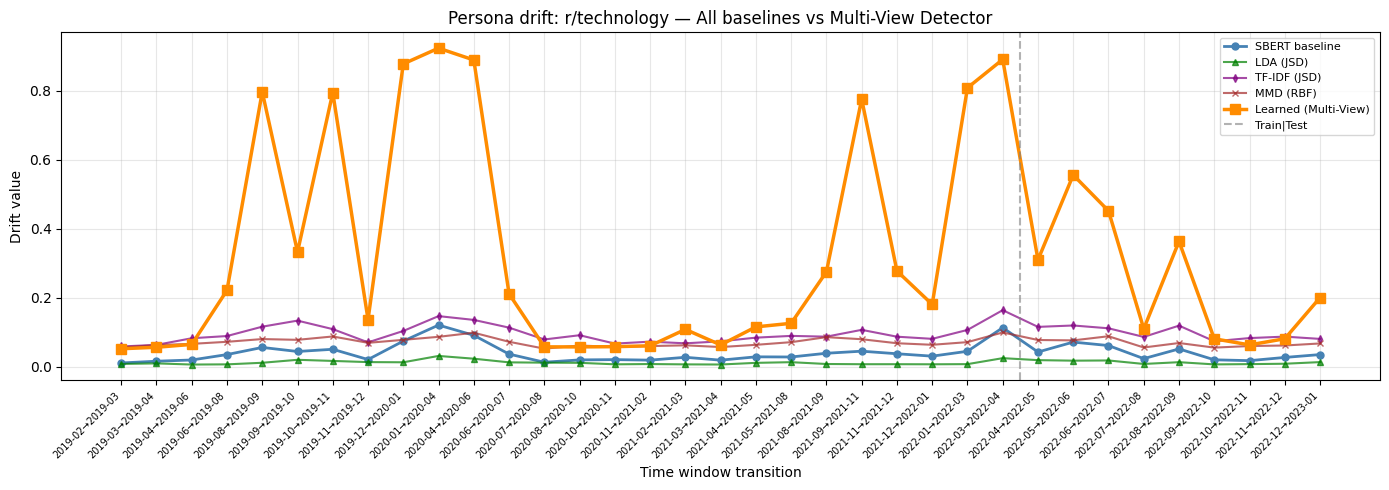

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
x = range(len(baseline_sbert))
ax.plot(x, baseline_sbert, "o-", lw=2, ms=5, label="SBERT baseline", color="steelblue")
ax.plot(x, lda_drift, "^-", lw=1.5, ms=4, label="LDA (JSD)", color="green", alpha=0.7)
ax.plot(x, tfidf_drift, "d-", lw=1.5, ms=4, label="TF-IDF (JSD)", color="purple", alpha=0.7)
ax.plot(x, mmd_drift, "x-", lw=1.5, ms=5, label="MMD (RBF)", color="brown", alpha=0.7)
ax.plot(x, learned_drift, "s-", lw=2.5, ms=7, label="Learned (Multi-View)", color="darkorange")

if len(train_window_ids) < len(window_ids):
    ax.axvline(x=len(train_window_ids)-1.5, color="gray", ls="--", alpha=0.6, label="Train|Test")

ax.set_xlabel("Time window transition")
ax.set_ylabel("Drift value")
ax.set_title(f"Persona drift: r/{config['data']['subreddit_config']} — All baselines vs Multi-View Detector")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels([f"{window_ids[i]}→{window_ids[i+1]}" for i in x], rotation=45, ha="right", fontsize=7)
plt.tight_layout()
plt.show()


## 6. Interpretability: top change point

In [9]:
from src.interpret import get_representative_posts, keyword_shifts, phrase_shifts, get_lda_topics

top_idx = int(np.argmax(learned_drift))
w_before, w_after = window_ids[top_idx], window_ids[top_idx + 1]

print(f"Top change point: {w_before} → {w_after}")
print("="*70)

rep_before = get_representative_posts(window_embeddings[w_before], persona_vectors[w_before], windows[w_before], 3)
rep_after = get_representative_posts(window_embeddings[w_after], persona_vectors[w_after], windows[w_after], 3)
print("Representative posts BEFORE:")
for i, t in enumerate(rep_before, 1):
    print(f"  {i}. {t[:200]}...")
print("\nRepresentative posts AFTER:")
for i, t in enumerate(rep_after, 1):
    print(f"  {i}. {t[:200]}...")

emerging_kw, declining_kw = keyword_shifts(windows[w_before], windows[w_after])
emerging_ph, declining_ph = phrase_shifts(windows[w_before], windows[w_after])
print("\nEmerging keywords:", [x[0] for x in emerging_kw[:8]])
print("Declining keywords:", [x[0] for x in declining_kw[:8]])
print("Emerging phrases:", [x[0] for x in emerging_ph[:5]])
print("Declining phrases:", [x[0] for x in declining_ph[:5]])

topics_before = get_lda_topics(windows[w_before], n_topics=3, top_n_words=5)
topics_after = get_lda_topics(windows[w_after], n_topics=3, top_n_words=5)
print("\nTopics BEFORE:")
for i, topic in enumerate(topics_before, 1):
    print(f"  Topic {i}:", [w for w, _ in topic[:5]])
print("Topics AFTER:")
for i, topic in enumerate(topics_after, 1):
    print(f"  Topic {i}:", [w for w, _ in topic[:5]])

Top change point: 2020-01 → 2020-04
Representative posts BEFORE:
  1. Cue malicious compliance brigade. Seriously though, cash needs to kept alive for as long as possible. It's a crumbling pillar of commercial privacy....
  2. Yeah it's kind of shocking how naive and out of touch these folks are. Privacy threads rocket to the top of all these subs yet having a choice to buy something with cash is somehow offensive to people...
  3. I didn't ask if you approve; the fact is your been tracked through systems like facial recognition and plate readers and your mobile phone. A few businesses going cashless won't effect the masses....

Representative posts AFTER:
  1. Man, I really appreciate all the techs putting in the work. As someone in the field, I get how hard that can be. On the other hand, Oh noooo all these companies Infamous for ripping off consumers, lyi...
  2. Greed is the virus ....people need to start to wake up to see this, and not support such companies! EVER!...
  3. Alright

---
**End of pipeline.** All steps use the `src` package; edit `config.yaml` to change data, model, or evaluation settings.